HW2 - Rishi Kiran Munuswamy

# Part 1

In [33]:
import sys
assert sys.version_info >= (3, 5)
import sklearn
assert sklearn.__version__ >= "0.20"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Checking for Missing Values & Replacing Zeros with Mean

In [41]:
df = pd.read_csv('Real estate.csv')
df.drop(['No'], axis=1, inplace=True)
df.replace(0, np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)
print("Missing values after cleaning:")
print(df.isna().sum())

Missing values after cleaning:
X1 transaction date    0
X2 house age           0
X3 bus station         0
X4 number of stores    0
X5 latitude            0
X6 longitude           0
Y price sq feet        0
dtype: int64


# 2. Analyzing Statistics & Extracting Year from X1 transaction date

In [43]:
print("Basic statistics of dataset:")
print(df.describe())
df['X1 transaction date'] = df['X1 transaction date'].astype(int)
print("Extracted year from transaction date:")
print(df[['X1 transaction date']].head())

Basic statistics of dataset:
       X1 transaction date  X2 house age  X3 bus station  X4 number of stores  \
count           414.000000    414.000000      414.000000           414.000000   
mean           2013.148971     18.471033     1083.885689             4.884726   
std               0.281967     10.785253     1262.109595             2.330651   
min            2012.667000      1.000000       23.382840             1.000000   
25%            2012.917000     11.525000      289.324800             3.000000   
50%            2013.167000     16.500000      492.231300             4.884726   
75%            2013.417000     28.150000     1454.279000             6.000000   
max            2013.583000     43.800000     6488.021000            10.000000   

       X5 latitude  X6 longitude  Y price sq feet  
count   414.000000    414.000000       414.000000  
mean     24.969021    121.533345        97.754106  
std       0.012409      0.015344        12.850456  
min      24.932070    121.473530 

# 3. Splitting Data & Selecting Important Features

In [46]:
train_df, test_df = train_test_split(df, test_size=0.15, random_state=17, shuffle=True)
short_list_features = ['X2 house age', 'X3 bus station', 'X4 number of stores', 'Y price sq feet']
print("Selected Features:", short_list_features)

Selected Features: ['X2 house age', 'X3 bus station', 'X4 number of stores', 'Y price sq feet']


# Normalize features

In [49]:
scaler = MinMaxScaler()
train_df[short_list_features[:-1]] = scaler.fit_transform(train_df[short_list_features[:-1]])
test_df[short_list_features[:-1]] = scaler.transform(test_df[short_list_features[:-1]])

# 4 Visualizing Data to Detect Outliers & Relationships


# 4.1 Boxplots
###      4.1.1 Boxplots for Each Feature


<function matplotlib.pyplot.show(close=None, block=None)>

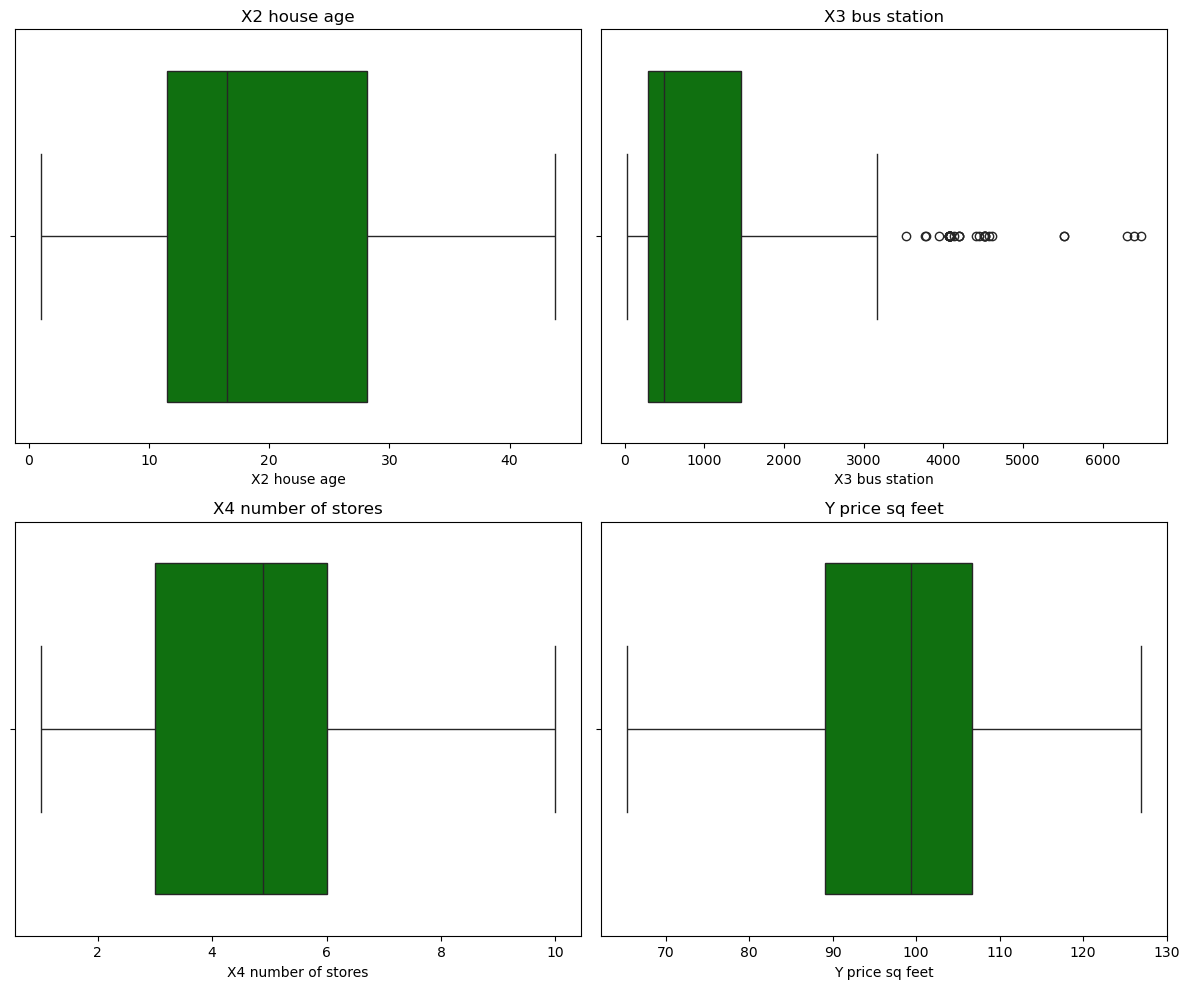

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feature in zip(axes.flatten(), short_list_features):
    sns.boxplot(data=df, x=feature, ax=ax, color='green')
    ax.set_title(f"{feature}")
plt.tight_layout()
plt.show


Box plot shows outliers in 'X3 bus station' and normal data for other features.

### 4.1.2 Combined Boxplot

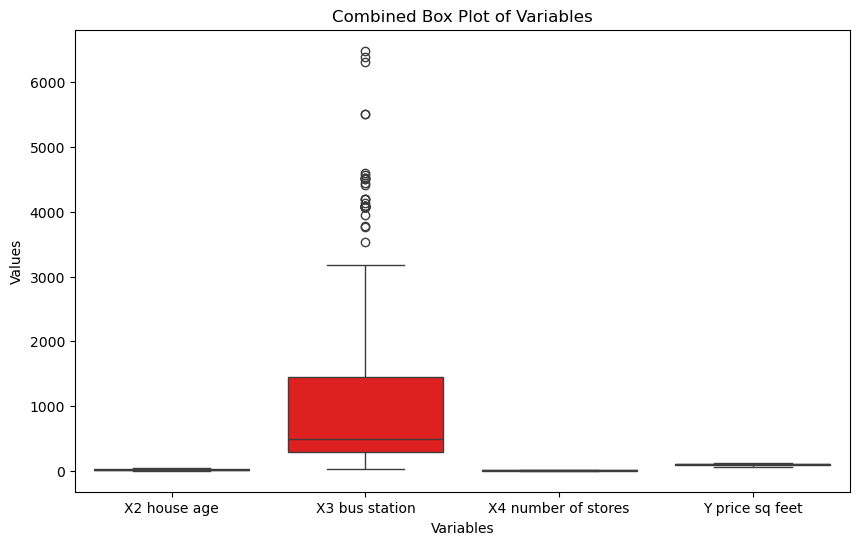

In [94]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['X2 house age', 'X3 bus station', 'X4 number of stores', 'Y price sq feet']] , color='red')
plt.title("Combined Box Plot of Variables")
plt.xlabel("Variables")
plt.ylabel("Values")
plt.show()

Combined overview of boxplots highlights similar results.

### 4.2 Histograms for Each Feature


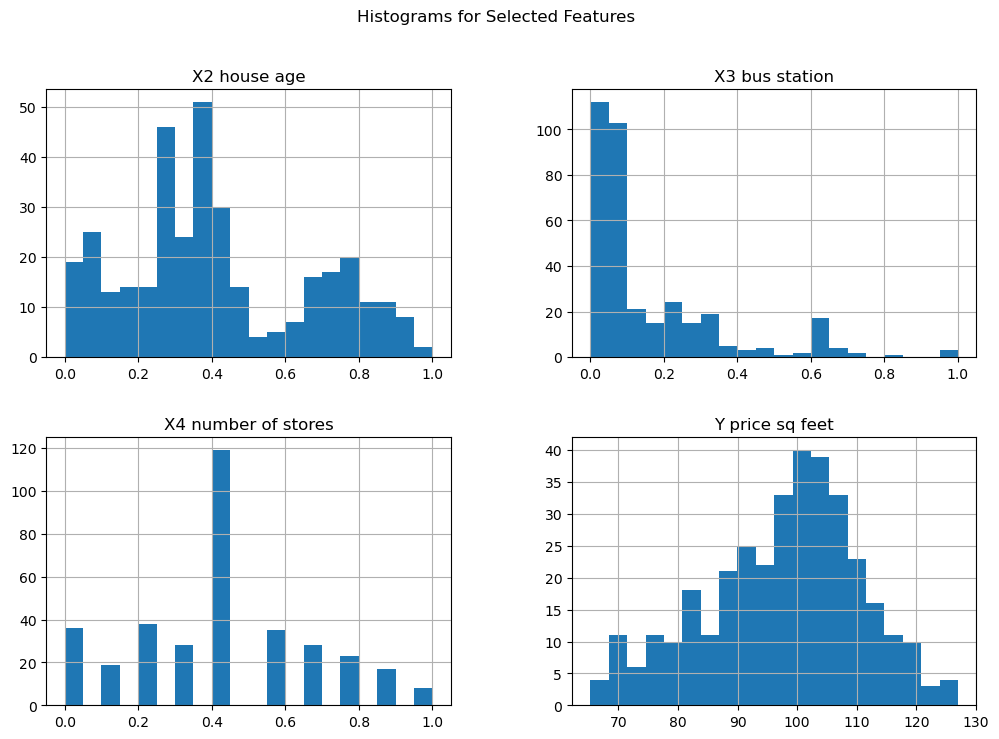

In [56]:
train_df[short_list_features].hist(bins=20, figsize=(12, 8))
plt.suptitle("Histograms for Selected Features")
plt.show()

### 4.3 Pairplot

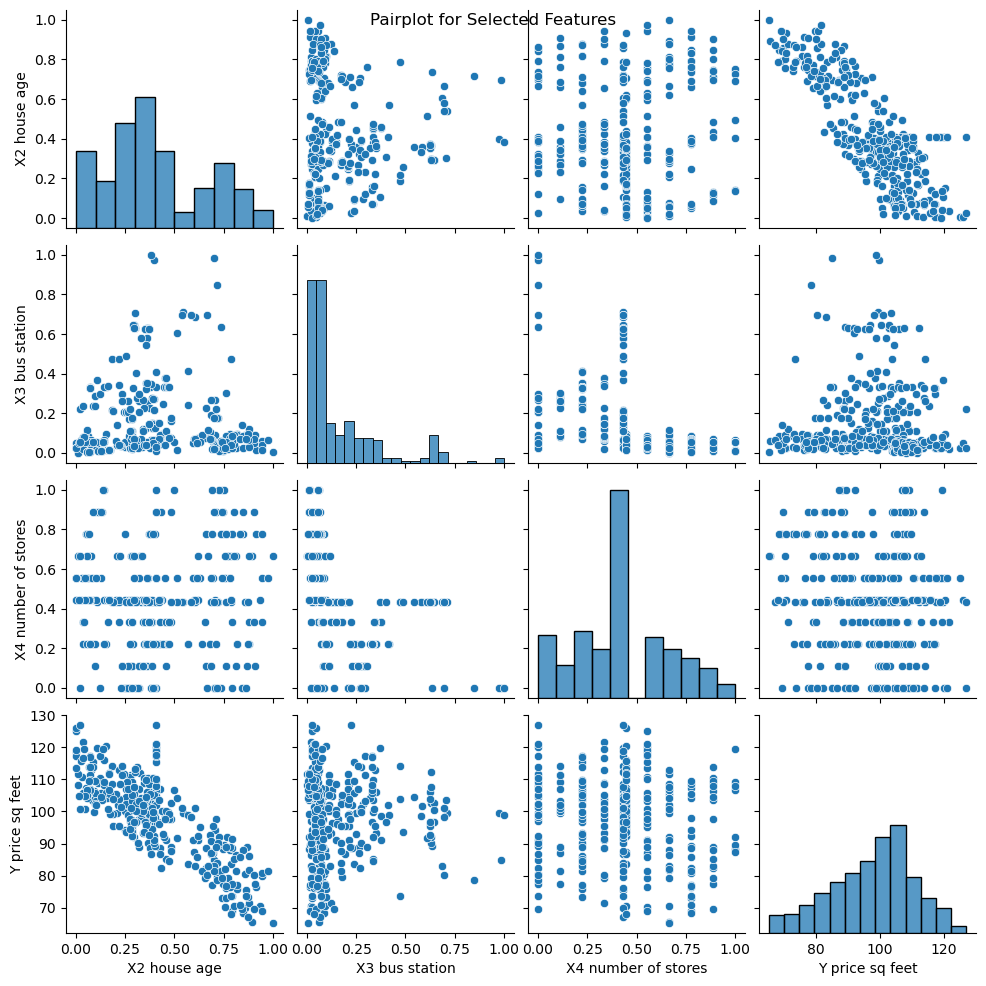

In [59]:
sns.pairplot(train_df[short_list_features])
plt.suptitle("Pairplot for Selected Features")
plt.show()

### 4.4 Correlation Heatmap


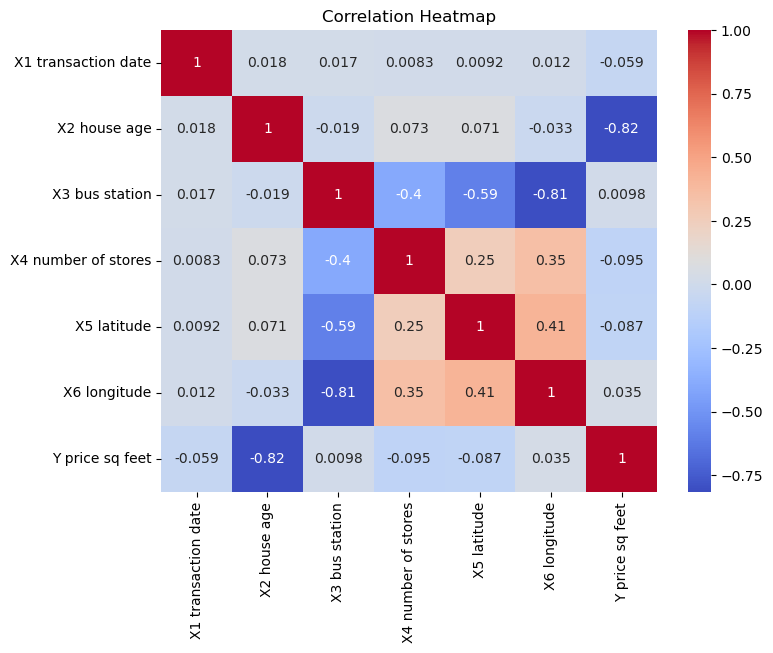

In [100]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 5. Running Regression to Find the Best Predictor


Simple Linear Regression tests each feature separately against Y price sq feet to see which has the strongest relationship.
X2 house age R² Score: 0.664


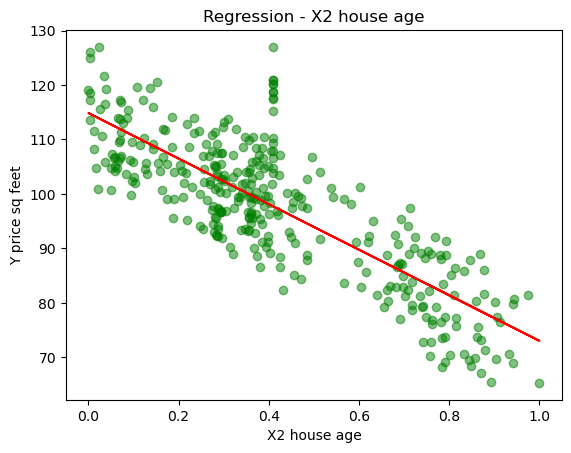

X3 bus station R² Score: 0.000


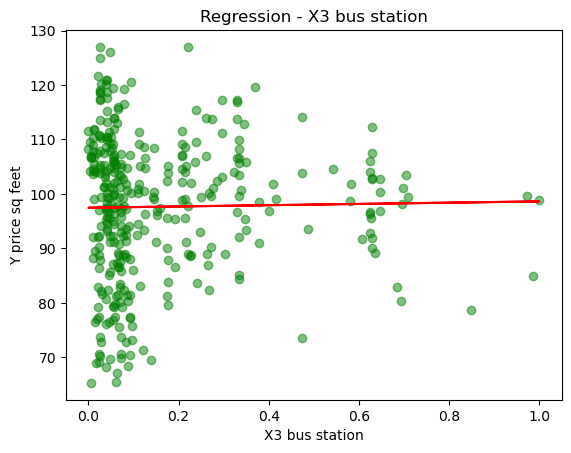

X4 number of stores R² Score: 0.010


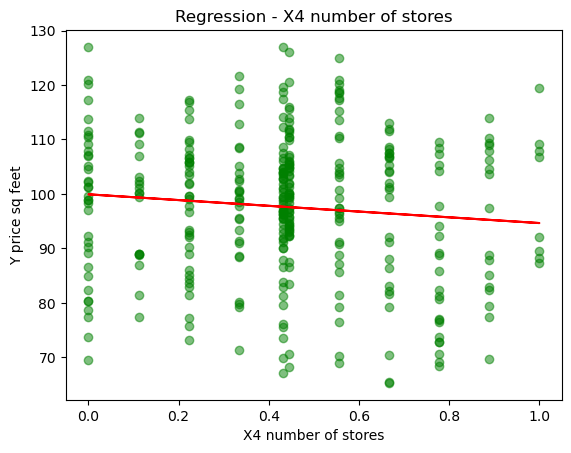

Multivariate R² Score: 0.665


In [89]:
print("Simple Linear Regression tests each feature separately against Y price sq feet to see which has the strongest relationship.")
for feature in short_list_features[:-1]:
    X_train = train_df[[feature]]
    y_train = train_df['Y price sq feet']
    model = LinearRegression()
    model.fit(X_train, y_train)
    r_sq = model.score(X_train, y_train)
    print(f"{feature} R² Score: {r_sq:.3f}")
    plt.scatter(X_train, y_train, color='green', alpha=0.5)
    plt.plot(X_train, model.predict(X_train), color='red')
    plt.xlabel(feature)
    plt.ylabel('Y price sq feet')
    plt.title(f'Regression - {feature}')
    plt.show()

# Multivariate Regression
X_train = train_df[short_list_features[:-1]]
y_train = train_df['Y price sq feet']
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Multivariate R² Score: {model.score(X_train, y_train):.3f}")


# Part 2

### Reflection and Conclusion

In this assignment, I followed a structured approach to handle data cleaning, visualization, and regression analysis. I addressed missing values and replaced zeros with the mean, ensuring consistent data quality. Extracting the year from the transaction date enabled focused insights. Visualization techniques, such as boxplots and heatmaps, helped identify outliers and correlations, highlighting 'X2 house age' as the most significant predictor (R² = 0.664). Regression analysis further confirmed this, while the multivariate model slightly improved performance (R² = 0.665).

Key challenges included selecting relevant attributes using 'model_score'e()` function and interpreting correlation results. These steps deepened my understanding of preprocessing, attribute selection, and evaluating model performance.